/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:181: UserWarning: 1 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11000']
  warnings.warn(
/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:455: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


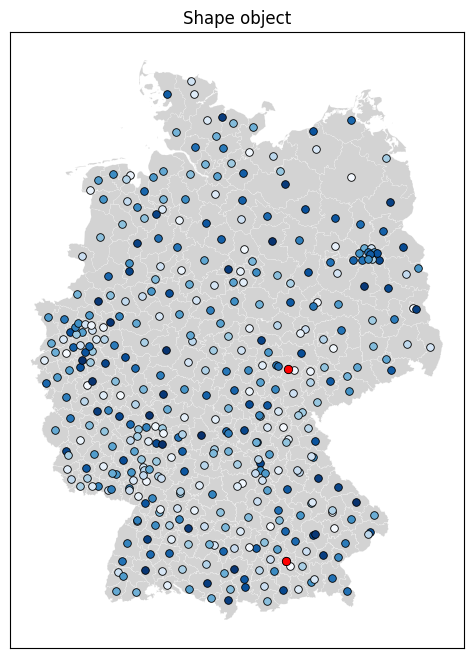

In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']
from src.dataloading.graphconstructor import GraphConstructor
epidata_nuts3 = EpiDataLoader('norovirus', data_env, nuts_level='nuts3', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
graphconstruction_nuts3 = GraphConstructor(graph_dir = 'data/graphs', 
                                     epidata   = epidata_nuts3,
                                     id_col    = 'node')
graphconstruction_nuts3.preview_shape_object(local_nodes = [391, 223])

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

from src.models._deepmodel import DeepModel
from src.dataloading.gnndataloader import GNNDataLoader

class SpatioTemporalGCN_GRU(nn.Module):
    def __init__(self, node_features, hidden_size, out_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size

        # Spatial module (shared across timesteps)
        self.gcn1 = GCNConv(node_features, hidden_size)
        self.gcn2 = GCNConv(hidden_size, hidden_size)

        # GRU: handles temporal dynamics of each node's spatial features
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)

        # Final prediction layer
        self.linear = nn.Linear(hidden_size, out_size)

    def forward(self, x_seq, edge_index, edge_weight=None, debug=False):
        """
        x_seq: Tensor of shape (batch_size=1, num_nodes, seq_len, node_features)
        """
        N, F_in, T  = x_seq.shape

        # Store spatial GCN output for each timestep
        spatial_outputs = []

        for t in range(T):
            x_t = x_seq[:, :, t]  # shape: (1, N, F_in)

            # Apply spatial GCN
            x1 = F.relu(self.gcn1(x_t, edge_index, edge_weight))
            x2 = F.relu(self.gcn2(x1, edge_index, edge_weight))  # shape: (N, hidden_size)
            spatial_outputs.append(x2)

        # Stack GCN outputs into a sequence: shape (N, T, hidden_size)
        x_spatial_seq = torch.stack(spatial_outputs, dim=1)

        # GRU expects input shape: (batch, seq_len, features)
        # So we process each node's temporal sequence individually
        x_spatial_seq = x_spatial_seq.permute(0, 1, 2)  # already (N, T, hidden)

        # GRU needs (batch, seq_len, input_size) => reshape for per-node GRU
        gru_input = x_spatial_seq  # (N, T, hidden)
        gru_out, _ = self.gru(gru_input)  # Output: (N, T, hidden)

        # Take last timestep output (can use others like mean or attention)
        final_hidden = gru_out[:, -1, :]  # (N, hidden)


        out = self.linear(final_hidden)  # (N, out_size)
        return out



class SpatioTemporalGRUModel(DeepModel):
    """
    Purely spatial GCN model that does not use temporal axis.
    Useful to validate the use of graph-structure
    """
    def __init__(self, 
                 dataloader: GNNDataLoader, 
                 name: Optional[str] = None):
        super().__init__(dataloader, name=name)
        if not self.name:
            self.name = 'SpatialGCN'

        self.model_color = '#4ECDC4'
        self.dataloader = dataloader
        self.config_info['model'] = 'spatialgcnmodel'

    def set_model_hparams(self, 
                          hidden_size: int = 256,
                          num_layers: int = 1) -> 'SpatioTemporalGRUModel':
        """
        Initalizes SpatioTemporalGRUModel

        Parameters:
        ----------
        hidden_size: int = 256
        """
        self.model = SpatioTemporalGCN_GRU(
            node_features = len(self.gnn_dataloader.feature_columns),
            hidden_size   = hidden_size,
            out_size      = self.gnn_dataloader.prediction_horizon,
            num_layers    = num_layers
        ).to(self.device)

        model_hparams_config = {'hidden_size': hidden_size}

        self.config_info['model_hparams'] = model_hparams_config
        self._state['model_initialized'] = True

        return self


In [4]:
epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=1)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_selfmn').construct_dataloaders()
epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)



🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 1], edge_index=[2, 210], edge_weight=[210])
Epoch 1 train loss: 0.5200, val loss: 0.8396 ✓ (new best)
Epoch 2 train loss: 0.4236, val loss: 0.6283 ✓ (new best)
Epoch 3 train loss: 0.3642, val loss: 0.4979 ✓ (new best)
Epoch 4 train loss: 0.3269, val loss: 0.4186 ✓ (new best)
Epoch 5 train loss: 0.3036, val loss: 0.3710 ✓ (new best)
Epoch 6 train loss: 0.2880, val loss: 0.3415 ✓ (new best)
Epoch 7 train loss: 0.2763, val loss: 0.3216 ✓ (new best)
Epoch 8 train loss: 0.2670, val loss: 0.3076 ✓ (new best)
Epoch 9 train loss: 0.2593, val loss: 0.2970 ✓ (new best)
Epoch 10 train loss: 0.2529, val loss: 0.2890 ✓ (new best)
Epoch 11 train loss: 0.2474, val loss: 0.2825 ✓ (new best)
Epoch 12 train loss: 0.2426, val loss: 0.2776 ✓ (new best)
Epoch 13 train loss: 0.2385, val loss: 0.2736 

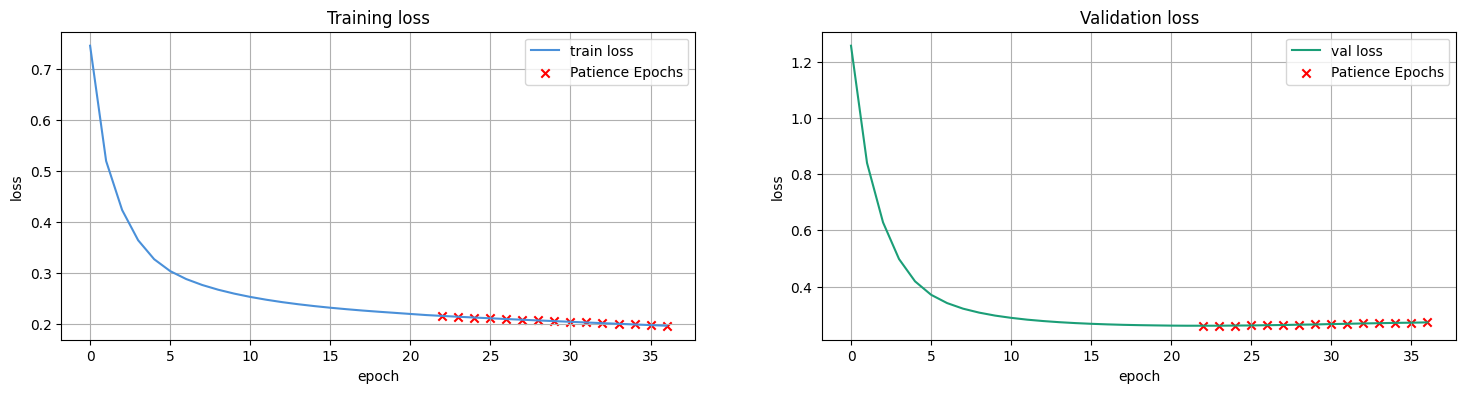

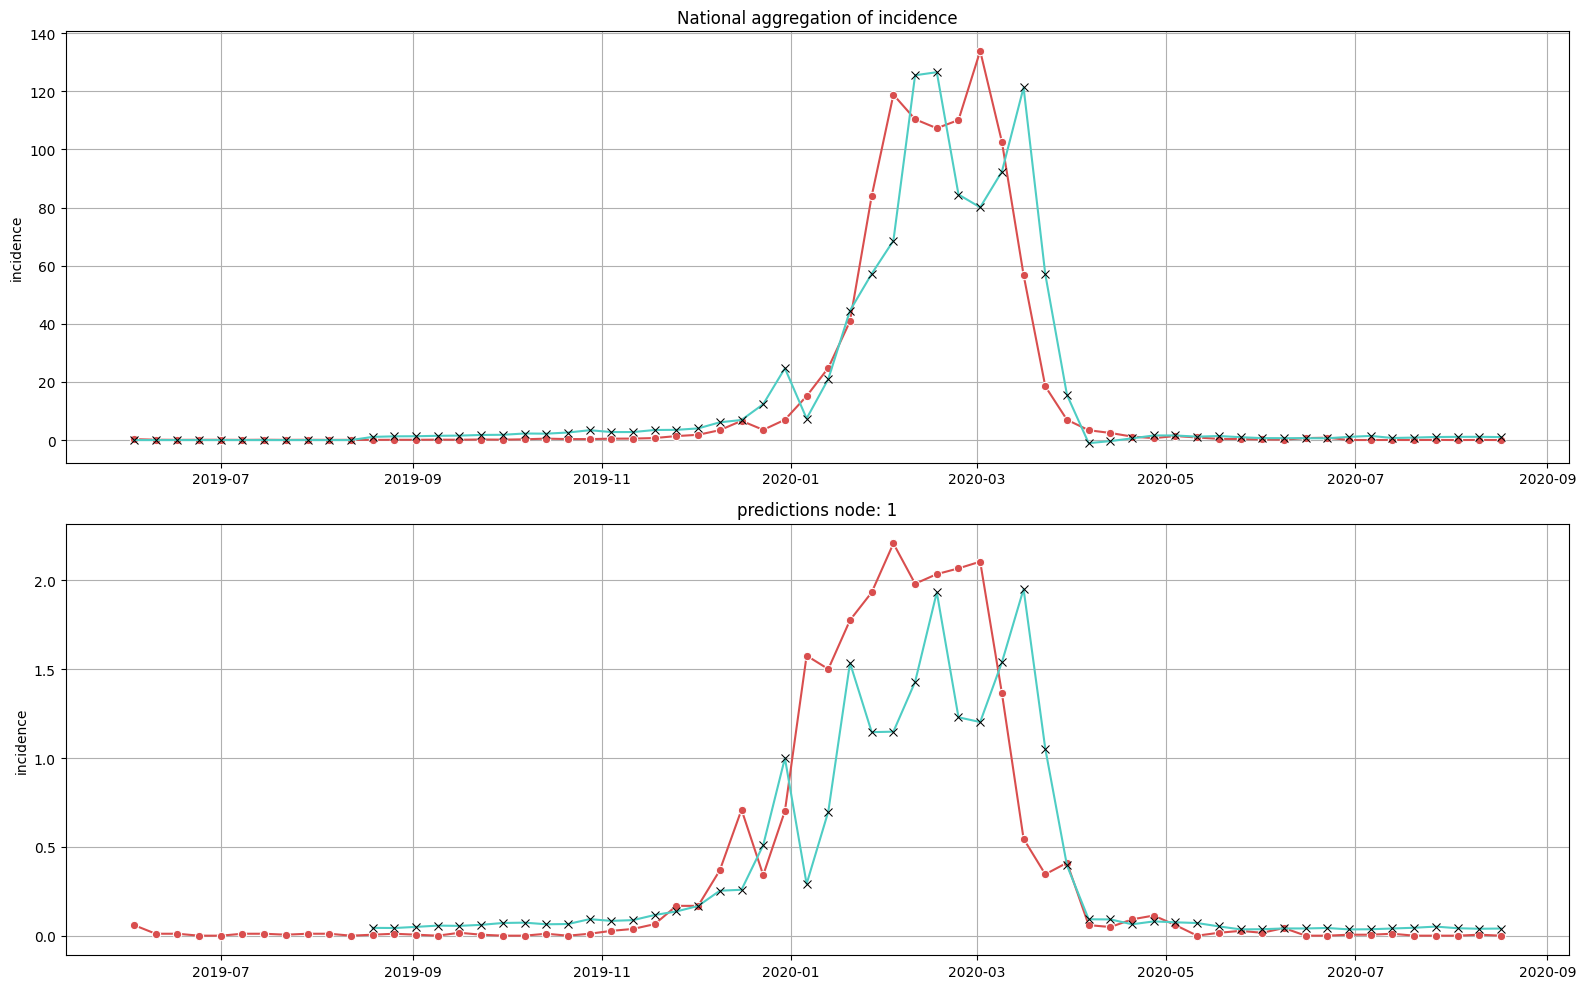

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

In [10]:
n_epochs = 100
lr       = 0.00002

ml1_id = SpatioTemporalGRUModel(name = f'baseline_spatial_gcn-identity_graph', dataloader=epidata_nuts2_bn)
ml1_id.set_model_hparams()
ml1_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_id.run_snapshot(debug=True)
ml1_id.train(verbose=2)
ml1_id.forecast()
ml1_id.show_forecasts(dataset='test', target_h = 0)